# Numerical precision

In [10]:
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt

from eleanor.jax.models import RNN, BrunoCell, BrunoParams

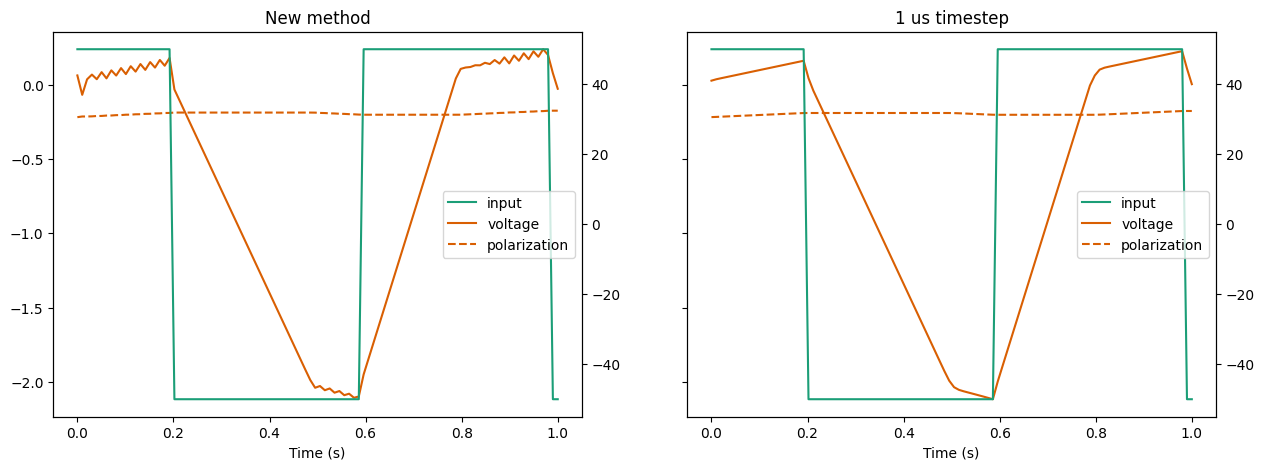

In [ ]:
key = jrandom.key(0)
keys = jrandom.split(key, 2)
t = jnp.linspace(0, 1, 100)
input = 1.0 * 50 * jnp.cos(8 * t)
input = 1.0 * 50 * jnp.sign(input) * (jnp.abs(input) > 0.5)
felif = RNN(
    BrunoCell((1,), BrunoParams(dt=1e-3), n_steps=1, return_states=True, key=keys[0])
)
s, v, p = felif(input)

t_us = jnp.linspace(0, 1, 100)
input_us = 1.0 * 50 * jnp.cos(8 * t_us)
input_us = 1.0 * 50 * jnp.sign(input_us) * (jnp.abs(input_us) > 0.5)
felif = RNN(
    BrunoCell((1,), BrunoParams(dt=1e-3), n_steps=1000, return_states=True, key=keys[0])
)
s_us, v_us, p_us = felif(input_us)

fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
ax = axs[0].twinx()
lns1 = ax.plot(t, input, c="#1b9e77", label="input")
lns2 = axs[0].plot(t, v, c="#d95f02", label="voltage")
lns3 = axs[0].plot(t, p, "--", c="#d95f02", label="polarization")

# added these three lines
lns = lns1 + lns2 + lns3
labs = [label.get_label() for label in lns]
ax.legend(lns, labs, loc=0)
axs[0].set_xlabel("Time (s)")
axs[0].set_title("New method")

ax = axs[1].twinx()
lns1 = ax.plot(t_us, input_us, c="#1b9e77", label="input")
lns2 = axs[1].plot(t_us, v_us, c="#d95f02", label="voltage")
lns3 = axs[1].plot(t_us, p_us, "--", c="#d95f02", label="polarization")

# added these three lines
lns = lns1 + lns2 + lns3
labs = [label.get_label() for label in lns]
ax.legend(lns, labs, loc=0)
axs[1].set_xlabel("Time (s)")
axs[1].set_title("1 us timestep")

plt.show()